# Experiment 5: Data Transformation and Visualization

**Description:**
Perform feature transformation and feature engineering on the cleaned dataset. Detect and analyze outliers using suitable statistical techniques. Visualize attribute distributions, correlations, trends, and relationships using appropriate plots and charts.

**Deliverables:**
- Python Notebook
- Visualization Graphs (at least 5)
- Outlier Analysis Report
- Interpretation of Results



In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')


## 1. Data Loading and Preprocessing


In [13]:
# Load the cleaned dataset
df = pd.read_csv('btc_cleaned.csv')

# Ensure date is datetime type
df['date'] = pd.to_datetime(df['date'])

# Display the first few rows
df.head()


,date,ticker,halving_era,days_since_halving,open,high,low,close,daily_change,daily_pct_change,daily_range,ma_7,ma_30,ma_200,volatility_30d,ema_12,ema_26,macd,macd_signal,rsi_14
0,2011-02-01,BTC,Genesis Era (50 BTC/block),199,0.520,0.85,0.5200,0.700,0.180,34.615385,0.3300,0.489014,0.384810,0.178373,9.753646,0.477095,0.415837,0.061258,0.041056,85.716762
1,2011-02-02,BTC,Genesis Era (50 BTC/block),200,0.700,0.76,0.6900,0.716,0.016,2.285714,0.0700,0.531729,0.398843,0.181706,9.711259,0.513850,0.438071,0.075778,0.048000,86.263305
2,2011-02-03,BTC,Genesis Era (50 BTC/block),201,0.716,0.75,0.6501,0.690,-0.026,-3.631285,0.0999,0.570129,0.411880,0.184727,9.789639,0.540950,0.456733,0.084217,0.055244,80.849378
3,2011-02-04,BTC,Genesis Era (50 BTC/block),202,0.690,0.88,0.6700,0.811,0.121,17.536232,0.2100,0.622271,0.428947,0.188378,10.108482,0.582496,0.482975,0.099521,0.064099,85.431750
4,2011-02-05,BTC,Genesis Era (50 BTC/block),203,0.811,0.92,0.8110,0.920,0.109,13.440197,0.1090,0.690986,0.449680,0.192604,10.225404,0.634420,0.515347,0.119073,0.075094,88.176380


## 2. Data Transformation and Feature Engineering
Here we create new features and transform existing ones to capture more insights:
1. **Log Transformation:** Applied to the `close` price to handle its exponential growth over time and reduce skewness.
2. **Time-Based Features:** Extracting `year`, `month`, and `day_of_week` to analyze seasonality.
3. **Rolling Volatility:** Creating a 7-day rolling standard deviation of the daily percentage change to represent short-term risk.


In [14]:
# 1. Log Transformation of Price
df['log_close'] = np.log(df['close'])

# 2. Time-Based Features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.day_name()

# 3. Short-term Rolling Volatility (7-day)
df['volatility_7d'] = df['daily_pct_change'].rolling(window=7).std()

# Drop rows with NaN values created by rolling functions
df.dropna(inplace=True)

print("Features engineered successfully. New dataset shape:", df.shape)
df[['date', 'close', 'log_close', 'year', 'month', 'day_of_week', 'volatility_7d']].head()


Features engineered successfully. New dataset shape: (5528, 25)


,date,close,log_close,year,month,day_of_week,volatility_7d
6,2011-02-07,0.8900,-0.116534,2011,2,Monday,14.023331
7,2011-02-08,0.9180,-0.085558,2011,2,Tuesday,8.147000
8,2011-02-09,1.0900,0.086178,2011,2,Wednesday,9.719305
9,2011-02-10,0.9803,-0.019897,2011,2,Thursday,11.056085
10,2011-02-11,1.0700,0.067659,2011,2,Friday,9.951961


## 3. Outlier Analysis
We will analyze outliers in the `daily_pct_change` (daily returns) to identify extreme market movements. We use two methods:
1. **Z-Score Method**: Identifies values that are more than 3 standard deviations away from the mean.
2. **Interquartile Range (IQR) Method**: Identifies values that fall below Q1 - 1.5*IQR or above Q3 + 1.5*IQR.

### Outlier Analysis Report


In [15]:
# Target variable for outlier detection
target_col = 'daily_pct_change'

# --- 1. Z-Score Method ---
z_scores = np.abs(stats.zscore(df[target_col]))
threshold_z = 3
outliers_z = df[z_scores > threshold_z]

# --- 2. IQR Method ---
Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df[target_col] < lower_bound) | (df[target_col] > upper_bound)]

# --- Report Generation ---
print("="*50)
print("OUTLIER ANALYSIS REPORT")
print("="*50)
print(f"Total records analyzed: {len(df)}")
print(f"Target Variable: {target_col} (Daily % Change)")

print("1. Z-Score Method (Threshold = 3 std dev):")
print(f"   - Number of outliers: {len(outliers_z)}")
print(f"   - Percentage of data: {(len(outliers_z) / len(df)) * 100:.2f}%")
print(f"   - Min outlier value: {outliers_z[target_col].min():.2f}%")
print(f"   - Max outlier value: {outliers_z[target_col].max():.2f}%")

print("2. IQR Method (1.5 * IQR rule):")
print(f"   - Number of outliers: {len(outliers_iqr)}")
print(f"   - Percentage of data: {(len(outliers_iqr) / len(df)) * 100:.2f}%")
print(f"   - Lower bound threshold: {lower_bound:.2f}%")
print(f"   - Upper bound threshold: {upper_bound:.2f}%")

print("Conclusion:")
if len(outliers_iqr) > len(outliers_z):
    print("The IQR method detected more outliers, which is common in financial data with fat tails.")
print("="*50)


OUTLIER ANALYSIS REPORT
Total records analyzed: 5528
Target Variable: daily_pct_change (Daily % Change)
1. Z-Score Method (Threshold = 3 std dev):
   - Number of outliers: 44
   - Percentage of data: 0.80%
   - Min outlier value: -57.21%
   - Max outlier value: 336.84%
2. IQR Method (1.5 * IQR rule):
   - Number of outliers: 582
   - Percentage of data: 10.53%
   - Lower bound threshold: -5.98%
   - Upper bound threshold: 6.42%
Conclusion:
The IQR method detected more outliers, which is common in financial data with fat tails.


## 4. Visualization
We will create 6 graphs to visualize distributions, relationships, and trends.


### Graph 1: Distribution of Daily Percentage Change
A histogram with a Kernel Density Estimate (KDE) to visualize the distribution of returns and observe the "fat tails" typical in crypto markets.


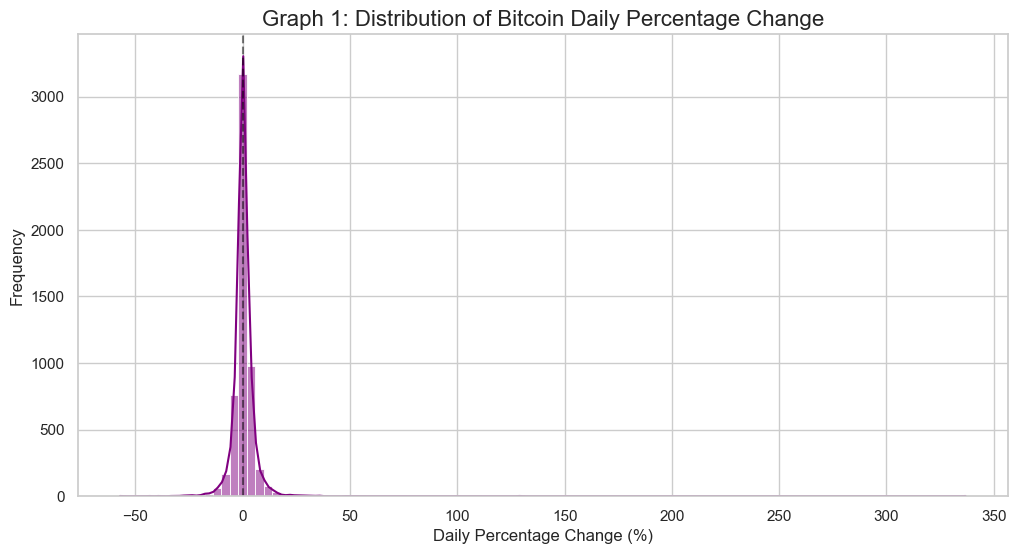

In [16]:
plt.figure(figsize=(12, 6))
sns.histplot(df['daily_pct_change'], bins=100, kde=True, color='purple')
plt.title('Graph 1: Distribution of Bitcoin Daily Percentage Change', fontsize=16)
plt.xlabel('Daily Percentage Change (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.show()


### Graph 2: Boxplots of Daily Percentage Change by Halving Era
To see how market volatility and return distributions have evolved across different Bitcoin halving eras.


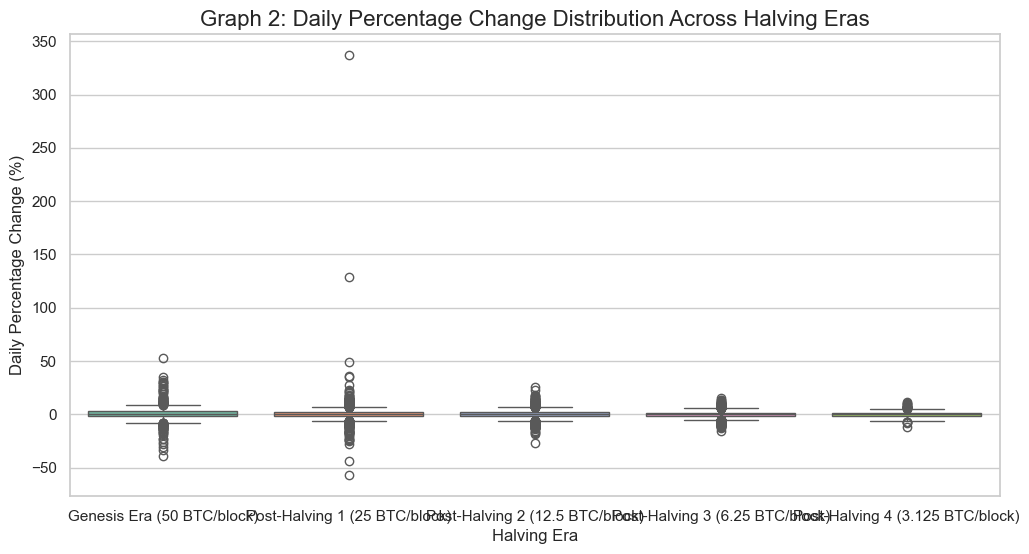

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='halving_era', y='daily_pct_change', data=df, palette='Set2')
plt.title('Graph 2: Daily Percentage Change Distribution Across Halving Eras', fontsize=16)
plt.xlabel('Halving Era', fontsize=12)
plt.ylabel('Daily Percentage Change (%)', fontsize=12)
plt.show()


### Graph 3: Correlation Heatmap
Visualizing the linear relationship between key numerical variables (price, moving averages, technical indicators).


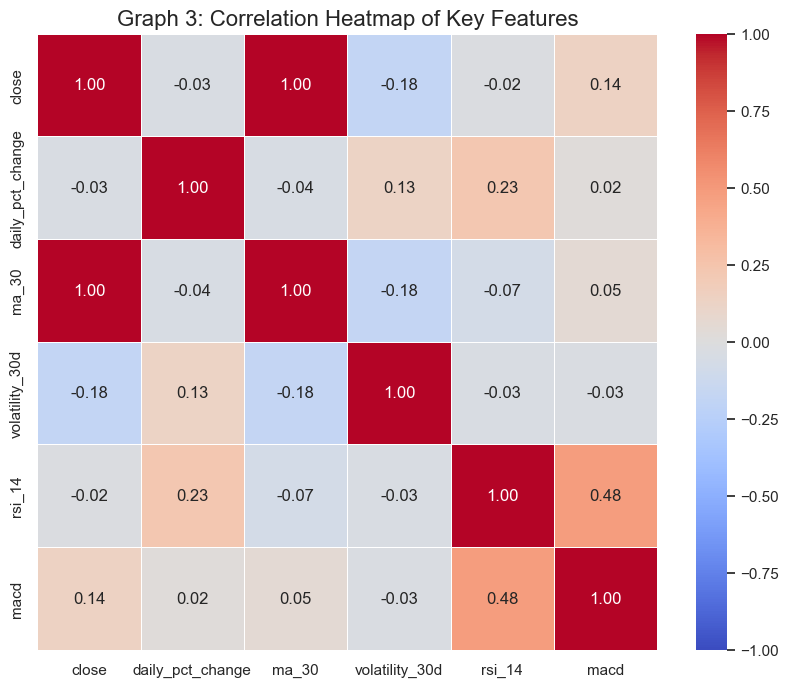

In [18]:
# Select numerical columns for correlation
cols_to_correlate = ['close', 'daily_pct_change', 'ma_30', 'volatility_30d', 'rsi_14', 'macd']
corr_matrix = df[cols_to_correlate].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Graph 3: Correlation Heatmap of Key Features', fontsize=16)
plt.show()


### Graph 4: Log Close Price and Long-term Moving Averages
Visualizing the long-term trend of Bitcoin using a logarithmic scale to properly represent exponential growth.


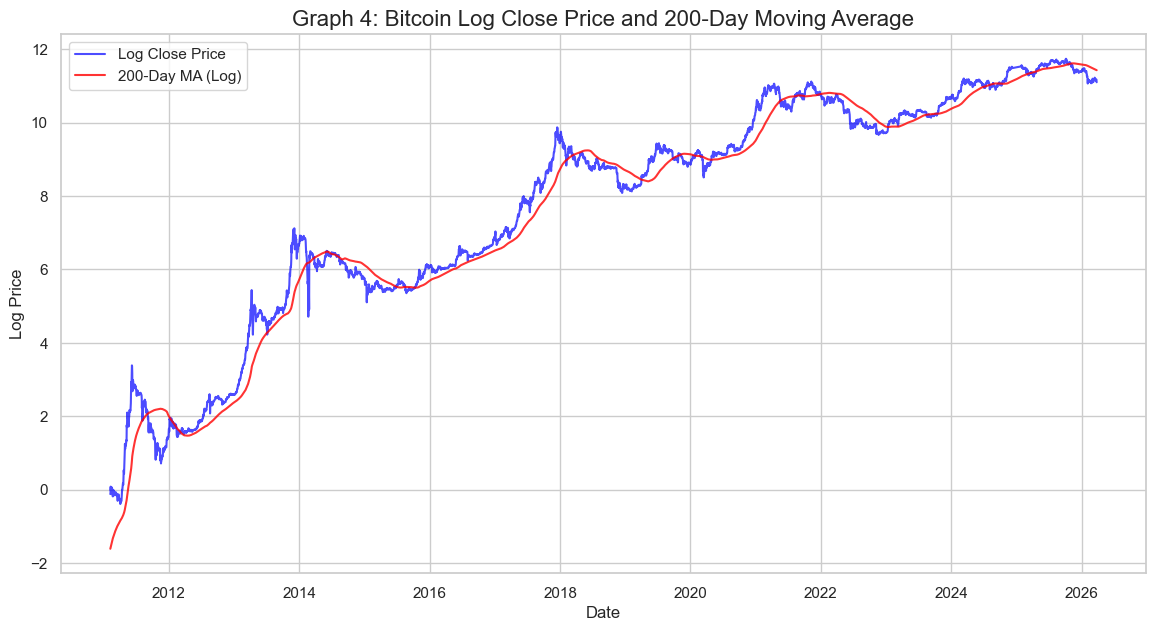

In [19]:
plt.figure(figsize=(14, 7))
plt.plot(df['date'], df['log_close'], label='Log Close Price', color='blue', alpha=0.7)
plt.plot(df['date'], np.log(df['ma_200']), label='200-Day MA (Log)', color='red', alpha=0.8)

plt.title('Graph 4: Bitcoin Log Close Price and 200-Day Moving Average', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log Price', fontsize=12)
plt.legend()
plt.show()


### Graph 5: Scatter Plot - RSI vs Daily Percentage Change
Exploring the relationship between momentum (RSI) and actual daily returns.


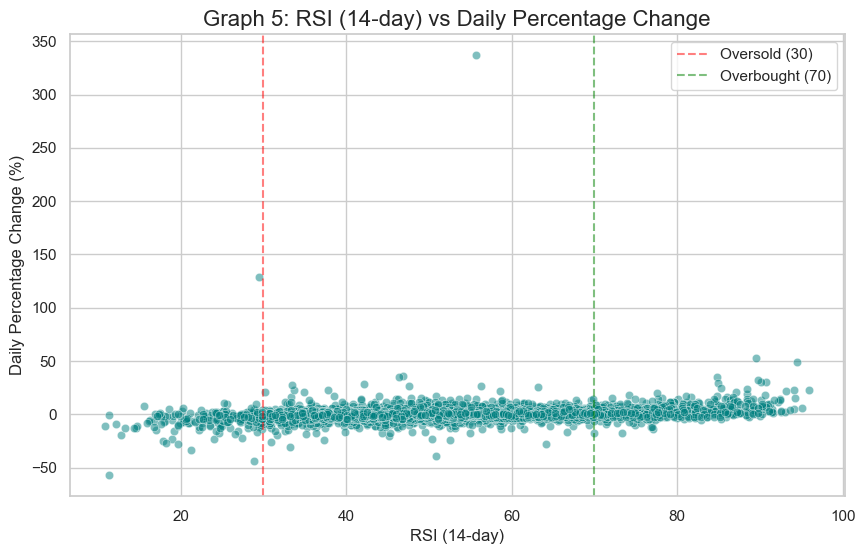

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='rsi_14', y='daily_pct_change', data=df, alpha=0.5, color='teal')
plt.title('Graph 5: RSI (14-day) vs Daily Percentage Change', fontsize=16)
plt.xlabel('RSI (14-day)', fontsize=12)
plt.ylabel('Daily Percentage Change (%)', fontsize=12)

# Add standard RSI threshold lines
plt.axvline(x=30, color='red', linestyle='--', alpha=0.5, label='Oversold (30)')
plt.axvline(x=70, color='green', linestyle='--', alpha=0.5, label='Overbought (70)')
plt.legend()
plt.show()


### Graph 6: Outliers Visualization Over Time
Plotting the daily percentage change over time and highlighting the anomalies (outliers) detected by the IQR method.


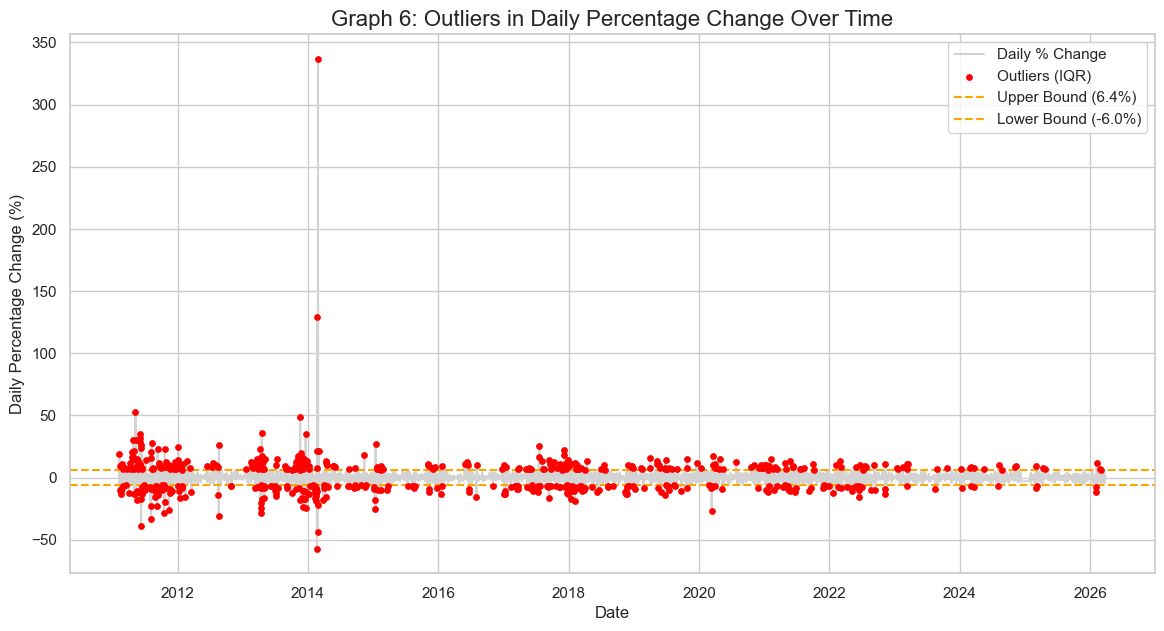

In [21]:
plt.figure(figsize=(14, 7))

# Plot all data in gray
plt.plot(df['date'], df['daily_pct_change'], color='lightgray', label='Daily % Change')

# Highlight IQR outliers in red
plt.scatter(outliers_iqr['date'], outliers_iqr['daily_pct_change'], color='red', label='Outliers (IQR)', s=15, zorder=5)

# Add threshold lines
plt.axhline(y=upper_bound, color='orange', linestyle='--', label=f'Upper Bound ({upper_bound:.1f}%)')
plt.axhline(y=lower_bound, color='orange', linestyle='--', label=f'Lower Bound ({lower_bound:.1f}%)')

plt.title('Graph 6: Outliers in Daily Percentage Change Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Percentage Change (%)', fontsize=12)
plt.legend()
plt.show()


## 5. Interpretation of Results

Based on our Data Transformation, Outlier Analysis, and Visualizations, we can draw several key conclusions:

1. **Distribution of Returns (Graph 1):** 
   - The histogram and KDE of `daily_pct_change` clearly demonstrate a peak around 0% but with significantly "fatter tails" than a normal distribution. This is typical for cryptocurrencies, indicating that extreme positive and negative days occur much more frequently than a standard normal distribution model would predict.

2. **Volatility Across Eras (Graph 2):**
   - The boxplots grouped by `halving_era` reveal that volatility tends to be different across cycles. Earlier eras typically exhibit wider interquartile ranges and more extreme outliers, indicating higher volatility in Bitcoin's younger, less mature market phases.

3. **Feature Correlation (Graph 3):**
   - The heatmap shows a strong positive correlation between `rsi_14` and `daily_pct_change` (as momentum indicators directly reflect recent price action). 
   - Interestingly, 30-day volatility doesn't correlate strongly in a linear fashion with price direction on a given day, meaning high volatility can happen in both bull and bear moves.

4. **Long-Term Trends (Graph 4):**
   - By visualizing the `close` price and its `ma_200` on a logarithmic scale, the exponential growth phases (bull markets) and subsequent consolidation phases (bear markets) are clearly visible. The log transformation normalizes the scale, showing that relative percentage gains were larger in early years.

5. **Momentum vs. Return (Graph 5):**
   - The scatter plot of RSI vs. daily returns shows an expected positive tilt (higher daily returns push the RSI up). Noticeably, extreme high daily returns rarely happen when RSI is already very low (oversold), and vice versa.

6. **Outliers Context (Outlier Analysis Report & Graph 6):**
   - The **Outlier Analysis Report** showed that the IQR method identified more outliers than the Z-score method. This confirms the non-normal distribution observed in Graph 1.
   - **Graph 6** visually places these outliers in a temporal context. We can observe "clusters" of outliers occurring during periods of market stress (e.g., major crashes or blow-off tops). This suggests that volatility and extreme events are auto-correlated (volatility clustering).

